# Project:

## Goal of Project:

The goal of this project is to analyze retail sales data to identify key spending patterns, top-selling products, and customer preferences across payment methods and purchase modes. By cleaning, transforming, and visualizing the dataset, the project aims to generate actionable business insights that can optimize sales strategy, improve inventory planning, and enhance customer experience.

## Detailed Objectives:

1. Identify & understand the structure of the dataset.
2. Clean and preprocess the dataset.
3. Perform EDA to explore spending patterns and relationships.
4. Identify top-selling products, preferred payment methods, and purchase modes.
5. Validate Calculations & Normalize Categories
6. Provide Business Recommendations: Suggest pricing, promotion, and channel strategies based on insights.

### Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import calendar
import itertools
import math
import warnings
warnings.filterwarnings('ignore')
warnings.warn("This warning will be hidden")
print("Script continues...")
df = pd.read_csv('retail_store_sales.csv')

Script continues...


#### Purpose of the libraries:
- pandas (pd) → for data loading, cleaning, and manipulation (read_csv, DataFrame, etc.).
- matplotlib.pyplot (plt) → for plotting graphs and charts.
- seaborn (sns) → for more visually appealing statistical plots (like heatmaps, boxplots, etc.).
- numpy (np) → for numerical operations (arrays, math functions, etc.).
- scipy.stats → for statistical tests (t-tests, z-scores, correlation significance, etc.).
- itertools → for creating combinations/permutations (useful for pairwise comparisons).
- math → for mathematical functions like floor, ceil, sqrt, etc.
- warnings → to handle or ignore unwanted warnings in the output.
- warnings.filterwarnings('ignore') hides all non-critical warnings so your output stays clean.
- pd.read_csv('retail_store_sales.csv') loads your dataset into a pandas DataFrame.

In [2]:
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


- df.head() shows the first 5 rows

In [3]:
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


- df.tail() shows the last 5 rows

#### Dataset Information:
- Total Rows: 12575
- Total Columns: 11

In [4]:
df.shape

(12575, 11)

- df.shape -> Returns a tuple (rows, columns) of your DataFrame

(helps to understand how big your dataset is (both records and features)).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Displays a summary of the DataFrame Such as:
- Column names
- Number of non-null values
- Data types (int64, float64, object, etc.)
- Memory usage

Purpose:
Helps you detect missing values quickly & Ensures data types are correct.

In [6]:
df.describe(include = 'all')

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.000000,11971.000000,11971.000000,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_2407494,CUST_05,Electric household essentials,Item_2_BEV,NaN,NaN,NaN,Cash,Online,2022-05-30,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.365912,5.536380,129.652577,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.743519,2.857883,94.750697,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN,NaN


Summary statistics for all columns (numeric + categorical).
- For numeric columns → count, mean, std, min, max, quartiles.
- For categorical columns → count, unique, top (most frequent), frequency.

Purpose:

- Quickly gives an overview of data distribution.
- Helps to find anomalies like negative prices, wrong data types, or very skewed values.

In [7]:
df.size

138325

It Returns the total number of elements in the DataFrame (rows × columns).

Purpose:
- Helps confirm dataset size in terms of cells.

In [8]:
df.ndim

2

Returns the number of dimensions of the DataFrame & Always 2 for a standard DataFrame (rows & columns).

Purpose:

- Helps confirm that the object is 2D.
- Useful when comparing with Series.

### Data Cleaning

#### Why important:
Clean data ensures accurate analysis and valid insights. Raw data may contain missing, invalid, or inconsistent entries.

#### Steps Involved:

- Checked missing values.
- Checked for duplicate entries.
- Corrected invalid data.
- Renamed coulmns
- Converted date strings to datetime format.

It is used to rename specific columns or rows by passing a dictionary to columns and (inplace = True) -> modifies the original "df" directly
Purpose:
- To clean column names (remove spaces, make lowercase, standardize format).
- To improve readability (e.g., converting Total Spent → total_spent).
- To avoid issues in code when column names have spaces or special characters.

In [9]:
df.rename(columns = {'Transaction ID': 'Transaction ID', 'Transaction Date': 'Transaction Date', 'Customer ID':'Customer ID', 'Category':'Product', 'Item':'Product_ID', 'Quantity':'Quantity', 'Price Per Unit': 'Price/Unit', 'Total Spent':'Total Spent','Location':'Purchase_Mode', 'Payment Method': 'Payment Method'}, inplace = True)
df

,Transaction ID,Customer ID,Product,Product_ID,Price/Unit,Quantity,Total Spent,Payment Method,Purchase_Mode,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [10]:
df['Product'].value_counts()

Product
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

In [11]:
df['Payment Method'].value_counts()

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

.value_counts():
Counts the number of occurrences of each unique value

Purpose:
- Helps in data analysis & visualization (e.g., pie charts, bar charts).
- Quickly tells you which payment method is most used.
- Useful for detecting rare categories that might need grouping or removal.

Insights:
Checking distribution of Payment Method values.

Recommendations:
Use normalize=True to see proportions. Consider dropna=False to check for missing values.

In [12]:
for col in df.columns:
    print(f"\nValue counts for column: {col}")
    print(df[col].value_counts(dropna=False))


Value counts for column: Transaction ID
Transaction ID
TXN_2407494    1
TXN_6867343    1
TXN_3731986    1
TXN_9303719    1
TXN_9458126    1
              ..
TXN_4206593    1
TXN_4396807    1
TXN_9634894    1
TXN_7563311    1
TXN_1809665    1
Name: count, Length: 12575, dtype: int64

Value counts for column: Customer ID
Customer ID
CUST_05    544
CUST_24    543
CUST_13    534
CUST_08    533
CUST_09    519
CUST_15    519
CUST_16    515
CUST_23    513
CUST_20    507
CUST_18    507
CUST_01    507
CUST_11    503
CUST_10    501
CUST_22    501
CUST_21    498
CUST_12    498
CUST_07    491
CUST_02    488
CUST_17    487
CUST_19    487
CUST_14    484
CUST_06    481
CUST_25    476
CUST_04    474
CUST_03    465
Name: count, dtype: int64

Value counts for column: Product
Product
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverage

### Data Type Corrections
- Converted Transaction Date to datetime using pd.to_datetime() for time-based analysis.
- Converted (Product, Payment Method,Purchase_Mode, Discount Applied) to category format.
- Runs df.info() to verify new data types and non-null counts.

#### Recommendation:
- After conversion, check df['Transaction Date'].isna().sum() to detect invalid dates.
- Clean strings before categorization to avoid duplicate categories due to typos.

In [13]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Transaction_Month_Name'] = df['Transaction Date'].dt.month_name()  
df['Transaction Day'] = df['Transaction Date'].dt.day_name()
df['Transaction Quarter'] = df['Transaction Date'].dt.quarter
month_order = list(calendar.month_name)[1:]
df['Transaction_Month_Name'] = pd.Categorical(
    df['Transaction_Month_Name'],
    categories=month_order,
    ordered=True
)

df['Product'] = df['Product'].astype('category')
df['Payment Method'] = df['Payment Method'].astype('category')
df['Purchase_Mode'] = df['Purchase_Mode'].astype('category')
df['Discount Applied'] = df['Discount Applied'].astype('category')
monthly_product_sales = df.groupby(['Transaction_Month_Name', 'Product'])['Total Spent'].sum().reset_index()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Transaction ID          12575 non-null  object        
 1   Customer ID             12575 non-null  object        
 2   Product                 12575 non-null  category      
 3   Product_ID              11362 non-null  object        
 4   Price/Unit              11966 non-null  float64       
 5   Quantity                11971 non-null  float64       
 6   Total Spent             11971 non-null  float64       
 7   Payment Method          12575 non-null  category      
 8   Purchase_Mode           12575 non-null  category      
 9   Transaction Date        12575 non-null  datetime64[ns]
 10  Discount Applied        8376 non-null   category      
 11  Transaction_Month_Name  12575 non-null  category      
 12  Transaction Day         12575 non-null  object

#### Find Duplicated Values
It is used to count the duplicated values in dataset.

In [14]:
print(df.duplicated().sum())

0


### Finding Missing Values & Fix Missing Values
Insight:

find missing values and fixed missing values using drop, drop_duplicates, fillna method to fill blank with given "values" from the user

In [15]:
df.isnull().sum()

Transaction ID               0
Customer ID                  0
Product                      0
Product_ID                1213
Price/Unit                 609
Quantity                   604
Total Spent                604
Payment Method               0
Purchase_Mode                0
Transaction Date             0
Discount Applied          4199
Transaction_Month_Name       0
Transaction Day              0
Transaction Quarter          0
dtype: int64

In [16]:
print(df.isnull().sum().sum())

7229


- To quickly check data diversity (e.g., number of unique customers, products, payment types).
- To detect categorical columns (columns with low unique counts often represent categories).

In [17]:
df.nunique()

Transaction ID            12575
Customer ID                  25
Product                       8
Product_ID                  200
Price/Unit                   25
Quantity                     10
Total Spent                 227
Payment Method                3
Purchase_Mode                 2
Transaction Date           1114
Discount Applied              2
Transaction_Month_Name       12
Transaction Day               7
Transaction Quarter           4
dtype: int64

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.isnull().sum()

Transaction ID               0
Customer ID                  0
Product                      0
Product_ID                1213
Price/Unit                 609
Quantity                   604
Total Spent                604
Payment Method               0
Purchase_Mode                0
Transaction Date             0
Discount Applied          4199
Transaction_Month_Name       0
Transaction Day              0
Transaction Quarter          0
dtype: int64

In [20]:
df.drop('Product_ID', axis=1 , inplace=True)
df.drop('Customer ID', axis=1 , inplace=True)
df['Price/Unit'] = df['Price/Unit'].fillna(df["Price/Unit"].median())
df["Quantity"] = df["Quantity"].fillna(math.floor(df["Quantity"].median()))
df['Total Spent'] = df['Price/Unit'] * df['Quantity']
df.isna().sum()

Transaction ID               0
Product                      0
Price/Unit                   0
Quantity                     0
Total Spent                  0
Payment Method               0
Purchase_Mode                0
Transaction Date             0
Discount Applied          4199
Transaction_Month_Name       0
Transaction Day              0
Transaction Quarter          0
dtype: int64

#### Insights:
- Drops columns: Product_ID and Customer ID (removes unnecessary data).
#### - Fills missing values:
- Price/Unit → filled with median (good for skewed data).
- Quantity → filled with median, rounded down using math.floor.
- Recomputes Total Spent = Price/Unit * Quantity (ensures consistency).
- Runs df.isna().sum() to check if any missing values remain.

##### Note: Fill 'Discount Applied' with ('Unknown') for further Analysis

In [21]:
df['Discount Applied'] = df['Discount Applied'].cat.add_categories(['Unknown'])
df['Discount Applied'] = df['Discount Applied'].fillna('Unknown')

In [22]:
missing_report = df.isnull().sum()
print("Missing values:\n", missing_report)

Missing values:
 Transaction ID            0
Product                   0
Price/Unit                0
Quantity                  0
Total Spent               0
Payment Method            0
Purchase_Mode             0
Transaction Date          0
Discount Applied          0
Transaction_Month_Name    0
Transaction Day           0
Transaction Quarter       0
dtype: int64


### Feature Engineering

#### 1) Revenue Category based on quantiles

In [23]:
q1 = df['Total Spent'].quantile(0.33)
q2 = df['Total Spent'].quantile(0.66)

def categorize_revenue(x):
    if x <= q1:
        return 'Low'
    elif x <= q2:
        return 'Medium'
    else:
        return 'High'

df['Revenue'] = df['Total Spent'].apply(categorize_revenue)
df['Revenue']

0          High
1          High
2           Low
3          High
4        Medium
          ...  
12570    Medium
12571       Low
12572    Medium
12573    Medium
12574       Low
Name: Revenue, Length: 12575, dtype: object

#### 2)Identify the Average Spend per Unit

In [24]:
df['Avg_Spend/Unit'] = df['Total Spent'] / df['Quantity']
df['Avg_Spend/Unit']

0        18.5
1        29.0
2        21.5
3        27.5
4        12.5
         ... 
12570    38.0
12571     6.5
12572    14.0
12573    14.0
12574    17.0
Name: Avg_Spend/Unit, Length: 12575, dtype: float64

In [25]:
iqr3 = df['Total Spent'].quantile(0.75)
df['Top sales'] = np.where(df['Total Spent'] > iqr3, 1, 0)
df['Top sales']

0        0
1        1
2        0
3        1
4        0
        ..
12570    0
12571    0
12572    0
12573    0
12574    0
Name: Top sales, Length: 12575, dtype: int64

#### 3)Check for the Bulk Order using 1 or 0 (threshold, here using Quantity > 10)

In [26]:
threshold = 10
df['Bulk Order'] = np.where(df['Quantity'] > threshold, 1, 0)

print(df[['Quantity', 'Total Spent', 'Avg_Spend/Unit', 'Revenue', 'Bulk Order']].head())

   Quantity  Total Spent  Avg_Spend/Unit Revenue  Bulk Order
0      10.0        185.0            18.5    High           0
1       9.0        261.0            29.0    High           0
2       2.0         43.0            21.5     Low           0
3       9.0        247.5            27.5    High           0
4       7.0         87.5            12.5  Medium           0


In [27]:
price_bins = [0, df['Price/Unit'].quantile(0.33),
                 df['Price/Unit'].quantile(0.66),
                 df['Price/Unit'].max()]
price_labels = ['Low', 'Medium', 'High']
df['Product Price Band'] = pd.cut(df['Price/Unit'],bins=price_bins,labels=price_labels,include_lowest=True)
df.head()

,Transaction ID,Product,Price/Unit,Quantity,Total Spent,Payment Method,Purchase_Mode,Transaction Date,Discount Applied,Transaction_Month_Name,Transaction Day,Transaction Quarter,Revenue,Avg_Spend/Unit,Top sales,Bulk Order,Product Price Band
0,TXN_6867343,Patisserie,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,April,Monday,2,High,18.5,0,0,Low
1,TXN_3731986,Milk Products,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,July,Sunday,3,High,29.0,1,0,Medium
2,TXN_9303719,Butchers,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,October,Wednesday,4,Low,21.5,0,0,Medium
3,TXN_9458126,Beverages,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown,May,Saturday,2,High,27.5,1,0,Medium
4,TXN_4575373,Food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,October,Sunday,4,Medium,12.5,0,0,Low


### Ensure no Negative value & Handling Invalid Outliers

In [28]:
df.drop_duplicates(inplace=True)

df = df[df['Quantity'] > 0]
df = df[df['Price/Unit'] > 0]
df = df[df['Total Spent'] > 0]
print("Invalid values removed, The Current Shape: ", df.shape)

Invalid values removed, The Current Shape:  (12575, 17)


#### Insights:
- Removes duplicate rows with drop_duplicates(inplace=True).

Filters dataset to keep only rows where:
- Quantity > 0
- Price/Unit > 0
- Total Spent > 0
Prints the new dataset shape after cleaning — helps track data reduction.
- use of df.shape print — consider adding percentage of rows removed for context.

### Handling Outliers

- #### Before Outlier

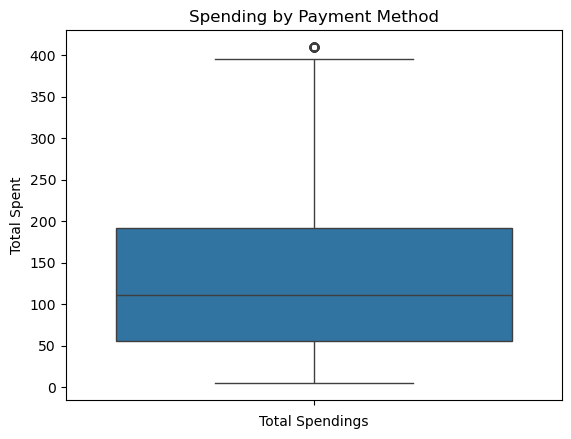

In [29]:
sns.boxplot(y='Total Spent', data=df)
plt.title("Spending by Payment Method")
plt.xlabel("Total Spendings")
plt.show()

#### Total Spent Distribution (Boxplot – Before Cleaning)

- Improved Understanding: The spending distribution showed a wide range with extreme high-value outliers.
- Upper Whisker Range: Some transactions exceeded unusually high spending amounts (likely data errors or very rare purchases).
- Lower Whisker: Very small purchases (near-zero values) were present, possibly incomplete/cancelled orders.
- IQR: Most spending was concentrated around the median, but skewed due to large outliers.

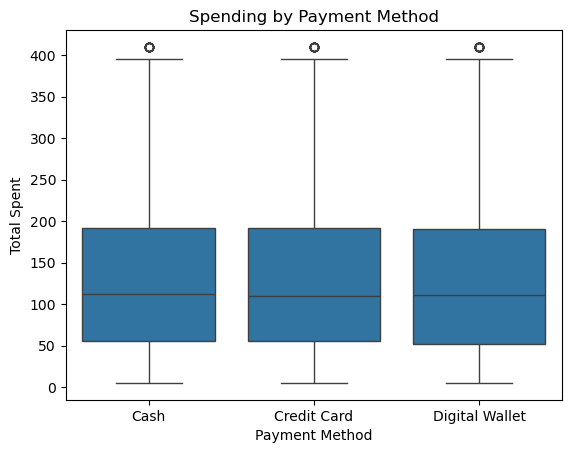

In [30]:
sns.boxplot(x='Payment Method', y='Total Spent', data=df)
plt.title("Spending by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")
plt.show()

#### Total Spent by Payment Method (Boxplot – Before Cleaning)

- Median Spending: Different payment methods showed varying central tendencies — some had much higher median spend.
- Spread (IQR): Some payment methods had a wider spending spread, indicating inconsistent purchase amounts.
- Outliers: High-value purchases dominated certain methods (e.g., credit cards), causing skewed visualization.

- ##### Formula for Removing Outliers:

In [31]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Total Spent"] >= lower) & (df["Total Spent"] <= upper)]

#### Insights:
- Calculates quartiles (Q1, Q3) and IQR for Total Spent.

Defines outlier bounds:
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Filters dataset to keep only rows within these bounds → removes outliers in Total Spent.

#### Insights:
- Compute Q1, Q3 per Payment Method using groupby(...).transform(...).
- Calculate IQR per group, defines (lower/upper bounds) for each Payment Method.
- Removes outliers group-wise to avoid unfairly dropping high spenders in categories with naturally higher spending.
- Using boxplot to confirm cleaned data distribution visually.

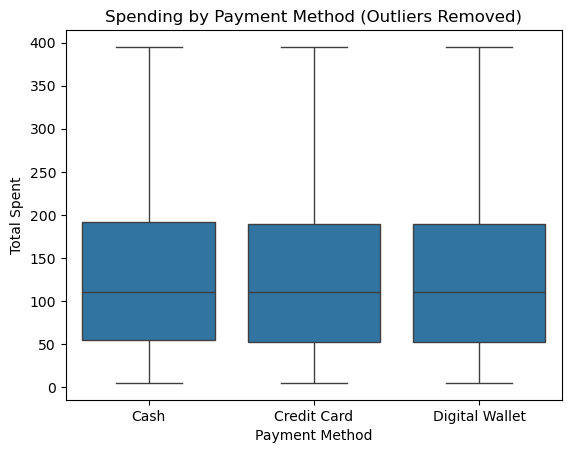

In [32]:
Q1 = df.groupby("Payment Method")["Total Spent"].transform(lambda x: x.quantile(0.25))
Q3 = df.groupby("Payment Method")["Total Spent"].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Total Spent"] >= lower) & (df["Total Spent"] <= upper)]
sns.boxplot(x="Payment Method", y="Total Spent", data=df)
plt.title("Spending by Payment Method (Outliers Removed)")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")
plt.show()

#### Group-Wise IQR Filtering (Outlier Removal)

- Improved Distribution: Extreme outliers removed for each payment method independently -> fairer representation.
- Upper & Lower Bounds: Transactions outside group-specific Q1−1.5×IQR & Q3+1.5×IQR were excluded.
- Result: Boxplots became tighter and more comparable across categories.
- Impact: Removed transactions that distorted overall mean/variance while keeping typical spend patterns intact.

- #### After Removing Outlier:

<Axes: xlabel='Price/Unit'>

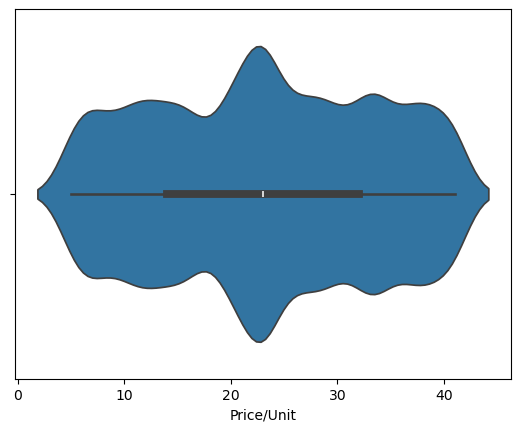

In [33]:
sns.violinplot(data= df, x='Price/Unit')

<Axes: xlabel='Quantity'>

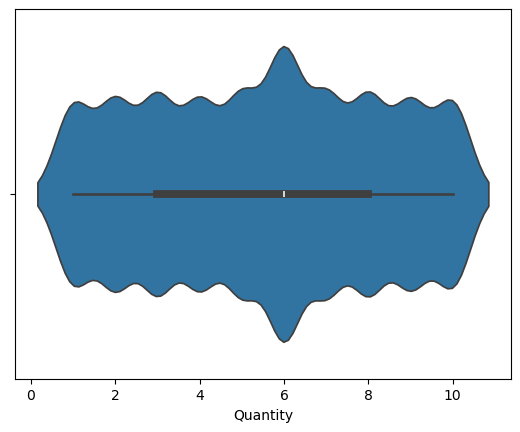

In [34]:
sns.violinplot(data= df, x='Quantity')

<Axes: xlabel='Total Spent'>

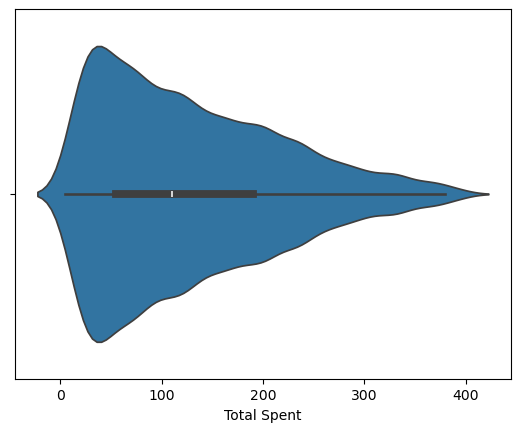

In [35]:
sns.violinplot(data= df, x='Total Spent')

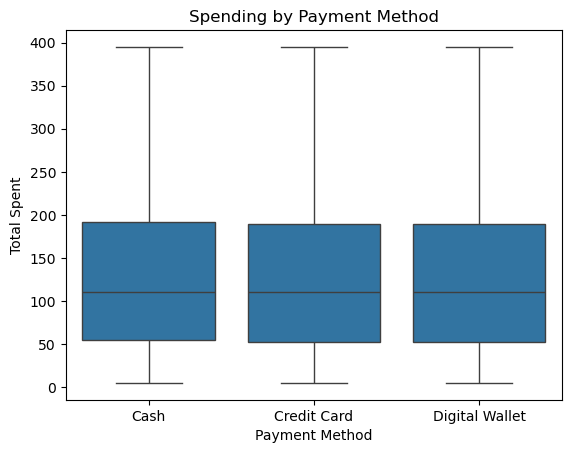

In [36]:
sns.boxplot(x='Payment Method', y='Total Spent', data=df)
plt.title("Spending by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")
plt.show()

## Key Metrics

# 1) Statisctical Analysis

#### ANOVA & Pairwise T-Tests(Payment Method vs Total Spent)

Interpretation & Insight:

- The ANOVA result suggests that the choice of Payment Method does not significantly affect the amount customers spend per transaction.
- The pairwise comparisons further confirm that none of the payment methods show statistically significant differences in spending behavior.
- Business Implication: Focus should instead be on product-level offers, bundling, or loyalty programs that drive higher transaction values.

In [37]:
methods = df['Payment Method'].dropna().unique()
groups = [df[df['Payment Method'] == m]['Total Spent'] for m in methods]

f_stat, p_val = stats.f_oneway(*groups)
print(f"\nANOVA Test: F-statistic = {f_stat:.3f}, p-value = {p_val:.4f}")

if p_val < 0.05:
    print("Result: Reject Null Hypothesis")
else:
    print("Result: Fail to Reject Null Hypothesis")

print("\n--- PAIRWISE T-TESTS ---")
for m1, m2 in itertools.combinations(methods, 2):
    g1 = df[df['Payment Method'] == m1]['Total Spent']
    g2 = df[df['Payment Method'] == m2]['Total Spent']
    t_stat, p = stats.ttest_ind(g1, g2, equal_var=False, nan_policy='omit')
    print(f"{m1} vs {m2}: t-test = {abs(t_stat):.4f}, p-value = {p:.4f} --> {'Significant changes occured' if p < 0.05 else 'No Significant changes'}")


ANOVA Test: F-statistic = 1.129, p-value = 0.3235
Result: Fail to Reject Null Hypothesis

--- PAIRWISE T-TESTS ---
Digital Wallet vs Credit Card: t-test = 0.1400, p-value = 0.8887 --> No Significant changes
Digital Wallet vs Cash: t-test = 1.3666, p-value = 0.1718 --> No Significant changes
Credit Card vs Cash: t-test = 1.2114, p-value = 0.2258 --> No Significant changes


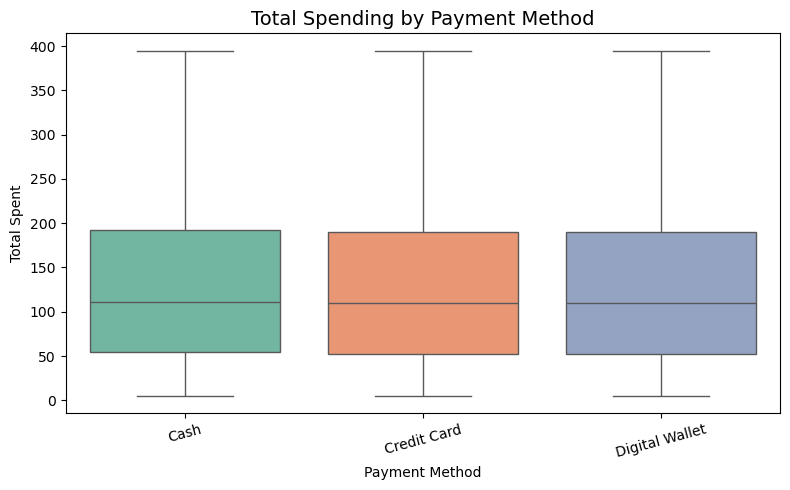

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Payment Method', y='Total Spent', data=df, palette='Set2')
plt.title("Total Spending by Payment Method", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Two-Sample T-Test (Online vs In-Store)

Interpretation & Insight:

- The result indicates that customers spend roughly the same amount regardless of whether they purchase online or in-store.
- This suggests that purchase mode does not influence transaction value significantly.
- Business Implication: Marketing efforts can be distributed evenly across both channels, focus on improving convenience and user experience rather than differentiating prices or promotions heavily by purchase mode.

In [39]:
online_spent = df[df['Purchase_Mode'] == 'Online']['Total Spent']
offline_spent = df[df['Purchase_Mode'] == 'In-store']['Total Spent']

t_stat, p_value = stats.ttest_ind(online_spent, offline_spent, equal_var=False)  

print("\nIndependent Two-Sample T-Test Results:")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Reject H₀, There is an Average Total Spent differs between Online & In-store modes.")
else:
    print("Conclusion: Fail to Reject H₀, There is No significant difference between Online & In-store modes.")


Independent Two-Sample T-Test Results:
T-statistic: 0.883
P-value: 0.3770
Conclusion: Fail to Reject H₀, There is No significant difference between Online & In-store modes.


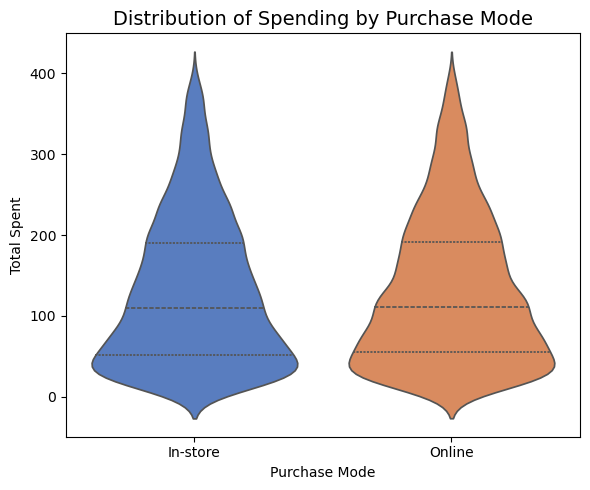

In [40]:
plt.figure(figsize=(6, 5))
sns.violinplot(x='Purchase_Mode', y='Total Spent', data=df, palette='muted', inner="quartile")
plt.title("Distribution of Spending by Purchase Mode", fontsize=14)
plt.xlabel("Purchase Mode")
plt.ylabel("Total Spent")
plt.tight_layout()
plt.show()

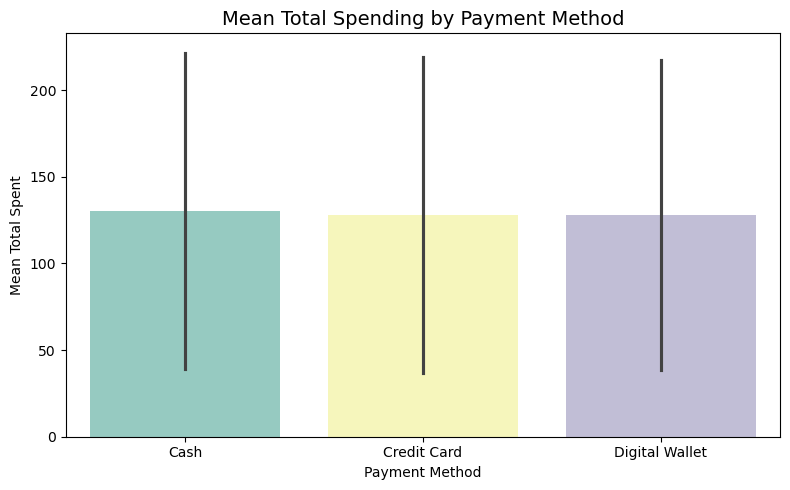

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Payment Method', y='Total Spent', data=df, ci='sd', palette='Set3')
plt.title("Mean Total Spending by Payment Method", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Mean Total Spent")
plt.tight_layout()
plt.show()

# 2) Descriptive Analysis

         Price/Unit      Quantity   Total Spent
count  12519.000000  12519.000000  12519.000000
mean      23.269231      5.538781    128.862968
std       10.436967      2.780500     90.611460
min        5.000000      1.000000      5.000000
25%       14.000000      3.000000     55.000000
50%       23.000000      6.000000    110.000000
75%       32.000000      8.000000    190.000000
max       41.000000     10.000000    395.000000


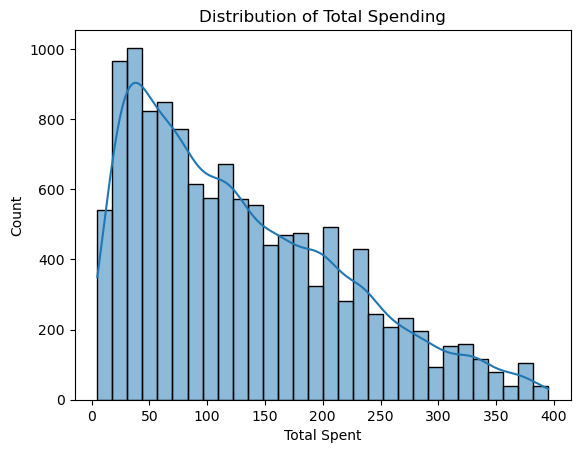

In [42]:
print(df[['Price/Unit','Quantity','Total Spent']].describe())
sns.histplot(df['Total Spent'], bins=30, kde=True)
plt.title("Distribution of Total Spending")
plt.show()

#### Distribution of Total Spending (Histogram + KDE)
- Shape: Positively skewed (right-tailed) — majority of customers spend on the lower end.
- Peak: Highest frequency cluster lies in lower spending range, tapering off for higher spend amounts.
- Effect of Cleaning: Reduced presence of extreme right-tail values → smoother KDE curve.

## Relationships Between Variables

Correlation matrix:
              Price/Unit  Quantity  Total Spent
Price/Unit     1.000000 -0.000696     0.628247
Quantity      -0.000696  1.000000     0.710265
Total Spent    0.628247  0.710265     1.000000


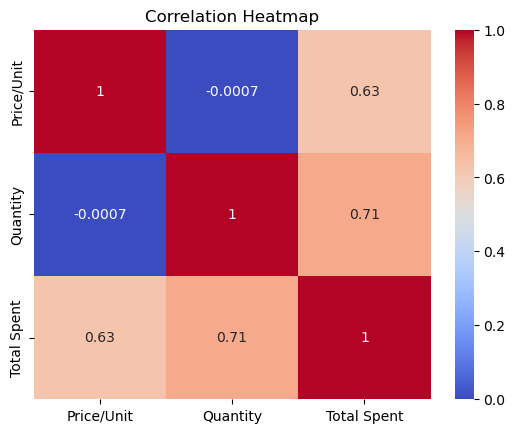

In [43]:
corr = df[['Price/Unit','Quantity','Total Spent']].corr()
print("Correlation matrix:\n", corr)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Relationships Between Variables (Correlation + Heatmap)

Price/Unit vs Quantity:
- Negative Correlation: Customers don’t necessarily buy fewer or more units based on price per unit, indicates independent purchase behavior.

Price/Unit vs Total Spent:
- Moderate Positive Correlation: Higher price per unit slightly increases total spending, as expected.

Quantity vs Total Spent: 
- Strong Positive Correlation: Major driver of total spending i.e., as quantity increases, total spending rises significantly.

Heatmap:

- Clearly highlights Quantity–Total Spent as the strongest relationship.
- Price-related variables show weaker influence, suggesting volume of purchase matters more than price per unit in this dataset.

# Exploratory Data Analysis(EDA)

## PERFORM UNIVARIATE, BIVARIATE AND MULTIVARIATE ANALYSIS

### 1) Univariate

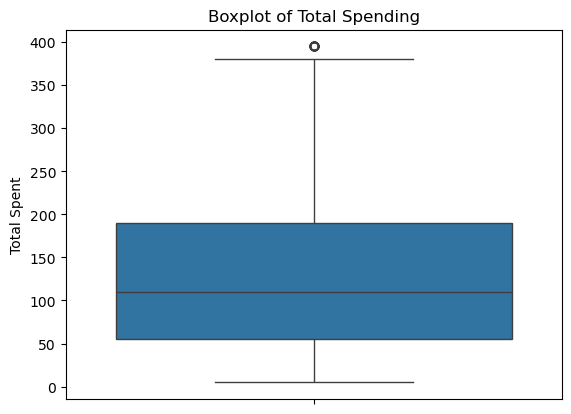

In [44]:
sns.boxplot(y=df['Total Spent'])
plt.title("Boxplot of Total Spending")
plt.ylabel("Total Spent")
plt.show()

#### INSIGHTS:
- Median Spending: The median total spending lies in the mid-range, showing the typical transaction value of customers.
- IQR (Middle 50%): Most transactions are tightly clustered within the interquartile range, indicates consistent spending behavior.
- Outliers: There is a few transactions still exist at the higher end, representing exceptionally large purchases — potentially either bulk buyers or special cases.
- Business Takeaway: Majority of customers spend moderately, but high-value outliers could be targeted for loyalty or premium marketing campaigns.

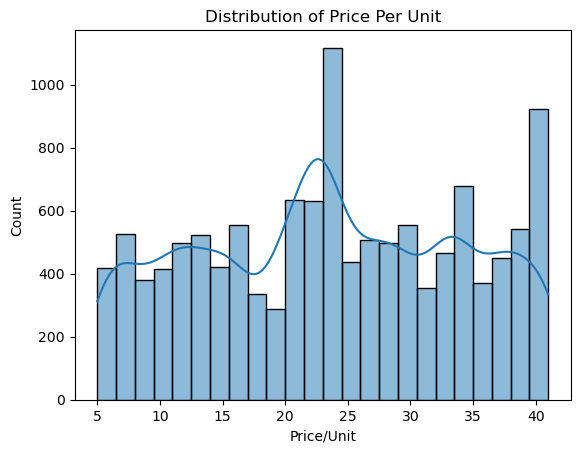

In [45]:
sns.histplot(df['Price/Unit'], kde=True)
plt.title("Distribution of Price Per Unit")
plt.show()

#### Insights: 

- The peak of the distribution (mode) is around the lower price range, suggesting that the majority of items are priced similarly.
- The Kernel Density Estimate (KDE) curve smooths out the distribution and helps visualize the overall trend, showing a gradual decline in frequency as the price per unit increases.
- There are few observations at higher price points, which might be considered as outliers or high-value items.

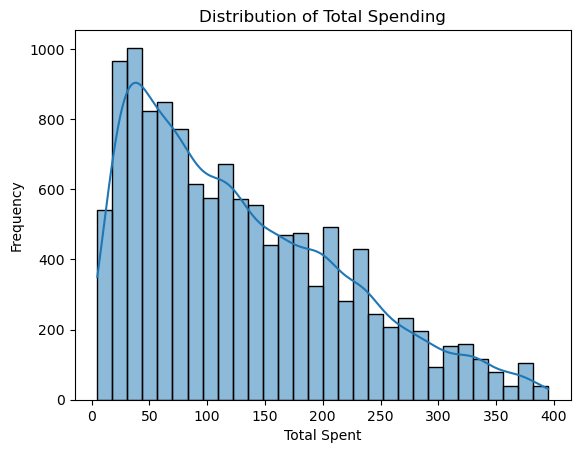

In [46]:
sns.histplot(df['Total Spent'], bins=30, kde=True)
plt.title("Distribution of Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

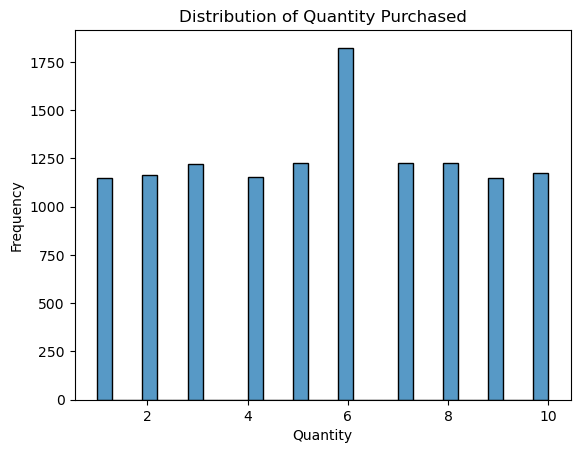

In [47]:
sns.histplot(df['Quantity'], bins=30, kde=False)
plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

#### INSIGHTS:

- The distribution of Quantity Purchased is right-skewed, indicating that most transactions involve purchasing a small number of units.
- The highest frequency of transactions occurs at lower quantity values, suggesting that customers typically purchase fewer items per transaction.
- There are very few transactions where a large quantity was purchased, which may represent bulk buying or special orders.
- This insight can help in inventory management and understanding typical customer purchasing behavior

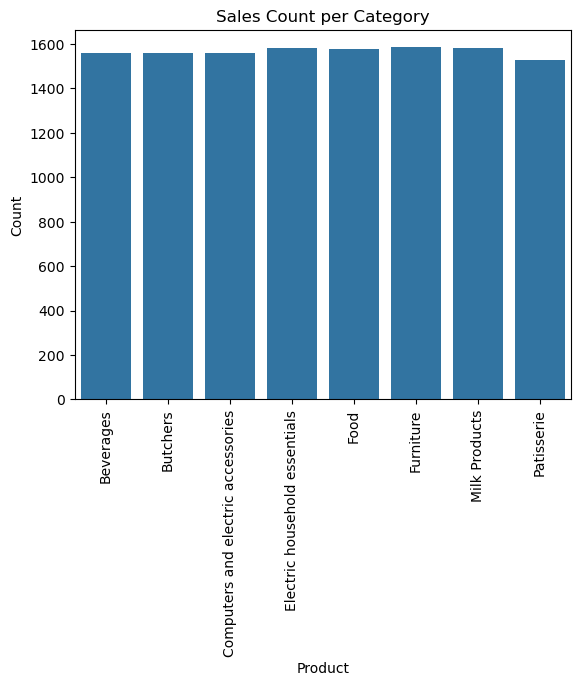

In [48]:
sns.countplot(x='Product', data=df)
plt.xticks(rotation=90)
plt.title("Sales Count per Category")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

#### INSIGHTS:

- The Sales Count per Product Category shows that some products are purchased much more frequently than others.
- A few product categories have a significantly higher number of sales, indicating they are more popular or in higher demand.
- Several products show a low sales count, which could suggest lower popularity, niche products, or possibly poor stock availability.
- The distribution is uneven across products, highlighting opportunities to investigate why certain products perform better (e.g., price, promotions, customer preference).
- This insight can help in making data-driven decisions related to product stocking, marketing strategies, or pricing adjustments.

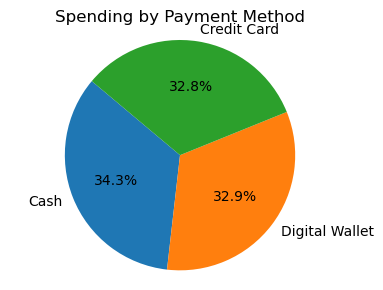

In [49]:
payment_count = df['Payment Method'].value_counts()
plt.figure(figsize=(4, 3))
plt.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%', startangle=140)
plt.title("Spending by Payment Method")
plt.axis('equal')  
plt.tight_layout()
plt.show()

#### INSIGHTS:

- The Spending by Payment Method shows the proportion of transactions completed using different payment methods.
- One payment method (e.g., Digital Wallet) accounts for the largest share of total transactions, indicating it is the most preferred by customers.
- Other payment methods, such as Credit Card, Debit Card, or Cash, make up smaller portions of the total, showing lesser usage compared to the dominant method.
- The distribution is relatively imbalanced, which may reflect customer convenience, promotions, or regional preferences.
- These insights can guide business decisions around payment method support, promotional offers, or improving the lesser-used methods to increase adoption.

### 2) Bi-variate

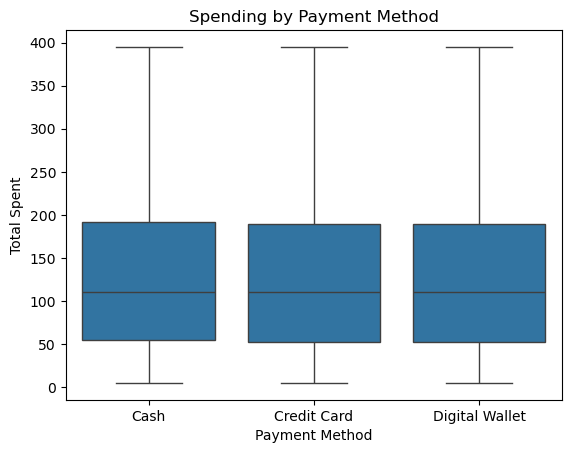

In [50]:
sns.boxplot(x='Payment Method', y='Total Spent', data=df)
plt.title("Spending by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")
plt.show()

#### INSIGHTS:

- The Spending by Payment Method box plot shows the distribution of total spending using different payment methods.
- The median total spent varies by payment method, indicating that customers using some methods tend to spend more per transaction.
- Some payment methods show a wider interquartile range (IQR), suggesting more variability in spending amounts, while others are more consistent.
- There are noticeable outliers (dots above whiskers) in certain payment methods, indicating a few transactions with unusually high spending compared to the typical range.
- This insight can help understand customer spending behavior by payment type and guide targeted promotions or adjustments to payment options.

Text(0.5, 0, 'Quantity')

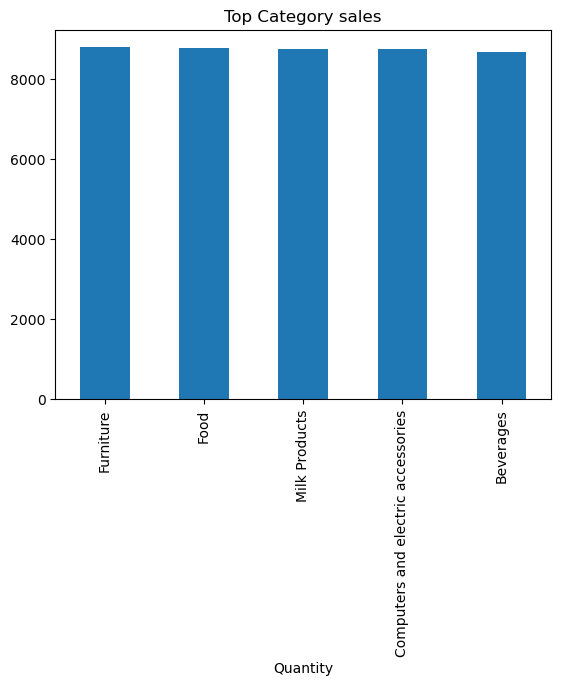

In [51]:
top_sales = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
top_sales.head().plot(kind='bar')
plt.title('Top Category sales')
plt.xlabel('Quantity')

#### INSIGHTS:

- Best-Selling Product: The product at the top of the bar chart has the highest total quantity sold, making it the most popular item among customers.
- Category Contribution: The top 5 products collectively contribute a major share of overall sales volume.
- Business Takeaway: Focused inventory management and promotions for these high-selling products can maximize revenue impact.

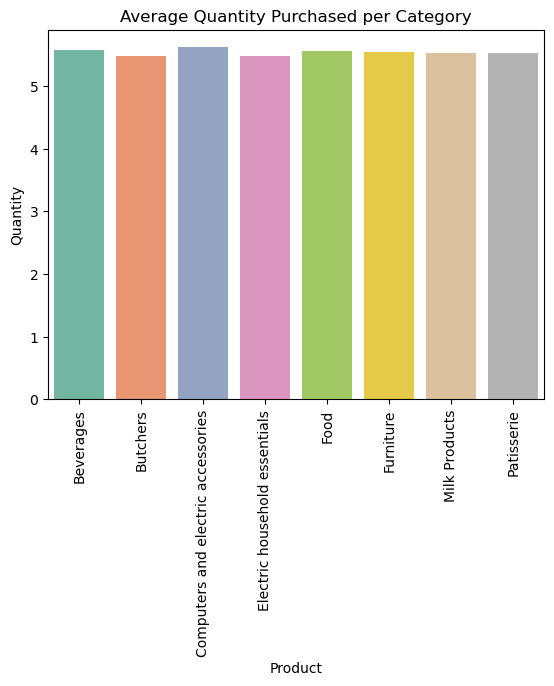

In [52]:
category_avg = df.groupby('Product')['Quantity'].mean().reset_index()
sns.barplot(x='Product', y='Quantity', data=category_avg, palette = 'Set2')
plt.xticks(rotation=90)
plt.title("Average Quantity Purchased per Category")
plt.show()

#### INSIGHTS:

- Average Demand Pattern: Certain products consistently have higher average purchase quantities, showing strong repeat or bulk buying behavior.
- Product Mix Insight: Some products have lower but steady purchase averages, indicating they are regular but at low-volume purchases.
  
Business Takeaway:
- For high-quantity products, focus on bulk discount strategies or bundle offers.
- For low-quantity products, explore cross-selling with popular items to boost overall sales.

<Axes: xlabel='Purchase_Mode'>

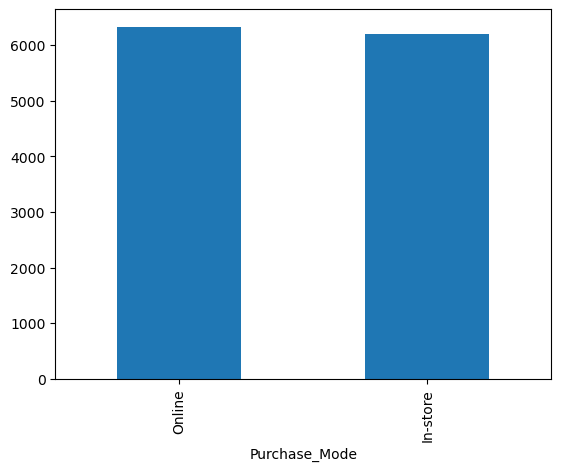

In [53]:
df['Purchase_Mode'].value_counts().plot(kind='bar')

#### INSIGHTS:

- Most Common Mode: The tallest bar indicates the most frequently used purchase mode (e.g., Online or In-Store) that shows customer channel preference.
- Distribution: Clear dominance of one purchase mode over others, so suggesting a strong inclination toward a specific buying channel.
- Less Popular Modes: Some modes have very few transactions, indicating limited customer adoption.

Business Takeaway:
- Strengthen operations and marketing in the most-used channel to maintain volume.
- Investigate why lesser-used modes underperform — could improve convenience or offer targeted incentives to boost usage.

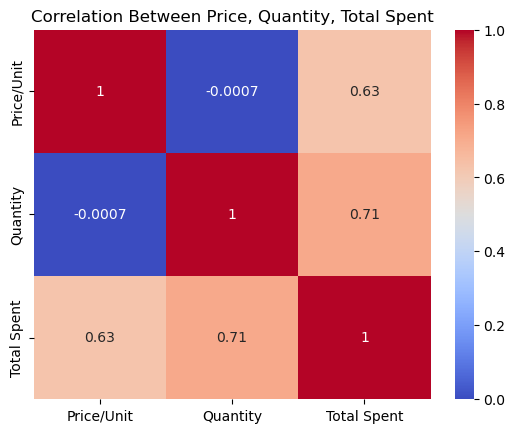

In [54]:
corr = df[['Price/Unit','Quantity','Total Spent']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Price, Quantity, Total Spent")
plt.show()

#### INSIGHTS:

### Quantity vs Total Spent:

- Strong Positive Correlation — Quantity is the main driver of total spending, confirming that sales volume directly impacts revenue.

### Price/Unit vs Total Spent:

- Moderate Positive Correlation — Higher unit prices slightly increase total spending but are less influential than quantity.

### Price/Unit vs Quantity:

- Weak / Slightly Negative Correlation — Customers do not drastically reduce quantity when price per unit rises, suggesting demand is relatively price-insensitive.

Business Takeaway:

Focus marketing on encouraging higher quantities per order, as it yields the biggest boost in total revenue.

Pricing changes should be tested carefully since they have limited but noticeable effects on total spending.

### 3) Multi-Variate

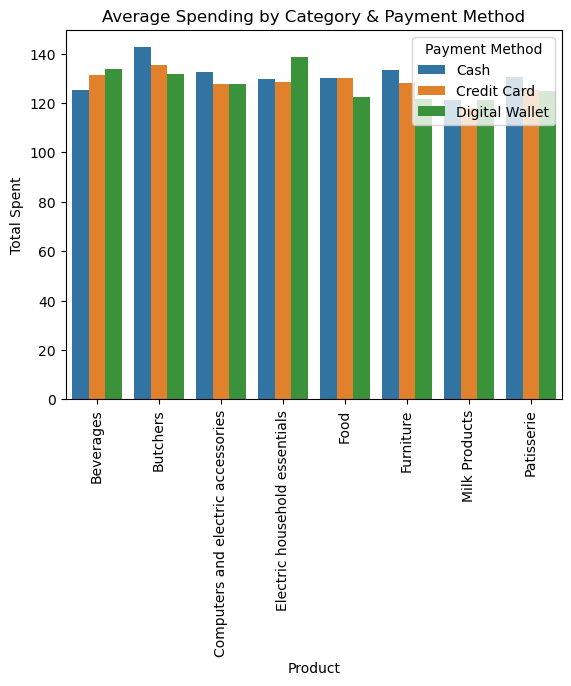

In [55]:
grouped = df.groupby(['Product','Payment Method'])['Total Spent'].mean().reset_index()
sns.barplot(x='Product', y='Total Spent', hue='Payment Method', data=grouped)
plt.xticks(rotation=90)
plt.title("Average Spending by Category & Payment Method")
plt.show()

### INSIGHTS:

- Category-Wise Spending: Some products consistently drive higher average spending, regardless of payment method — indicating they are premium or bulk-purchased items.
- Payment Method Preferences: Certain payment methods (e.g., Credit Card / UPI) dominate spending for specific products, suggesting preferred transaction modes.
- Variation Across Products: A few products show large gaps between payment methods, revealing potential behavioral differences (e.g., cash used for lower-value purchases, cards for higher-value ones).

Business Takeaway:

- Offer method-specific promotions (e.g., card cashback on top-selling categories).
- Ensure smooth payment experience across methods, especially for categories with high spending potential.

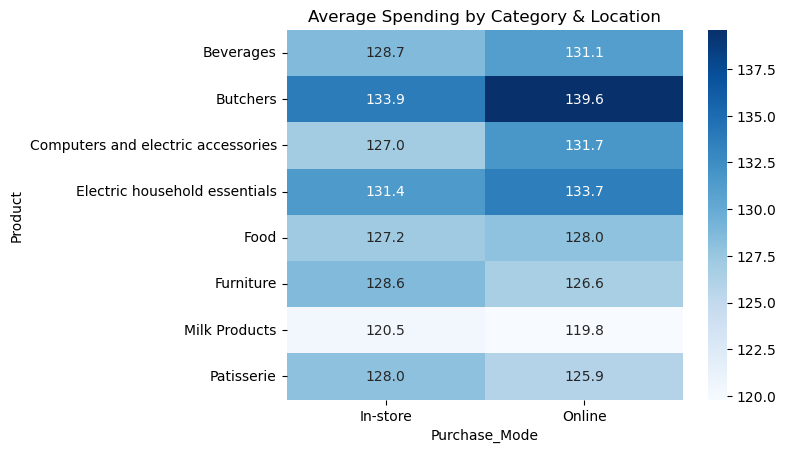

In [56]:
pivot = df.pivot_table(values='Total Spent', index='Product', columns='Purchase_Mode', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Average Spending by Category & Location")
plt.show()

#### INSIGHTS:

- Category-Wise Patterns: Certain products show consistently higher spending across all purchase modes, making them strong revenue contributors regardless of channel.
  
- Channel-Specific Insights:

- - Some products have much higher spending online, indicating they are preferred for digital purchases.
  - Others are stronger in in-store sales, hinting at impulse buying or products customers prefer to see physically.
  - Variation Across Purchase Modes: The heatmap visually highlights which categories underperform in a specific channel, helping identify areas for growth.

Business Takeaway:

- Optimize inventory allocation based on where each product sells most.
- Promote online-exclusive discounts for low-performing products online, or vice versa for in-store.
- Using this insight to personalize marketing campaigns by channel.

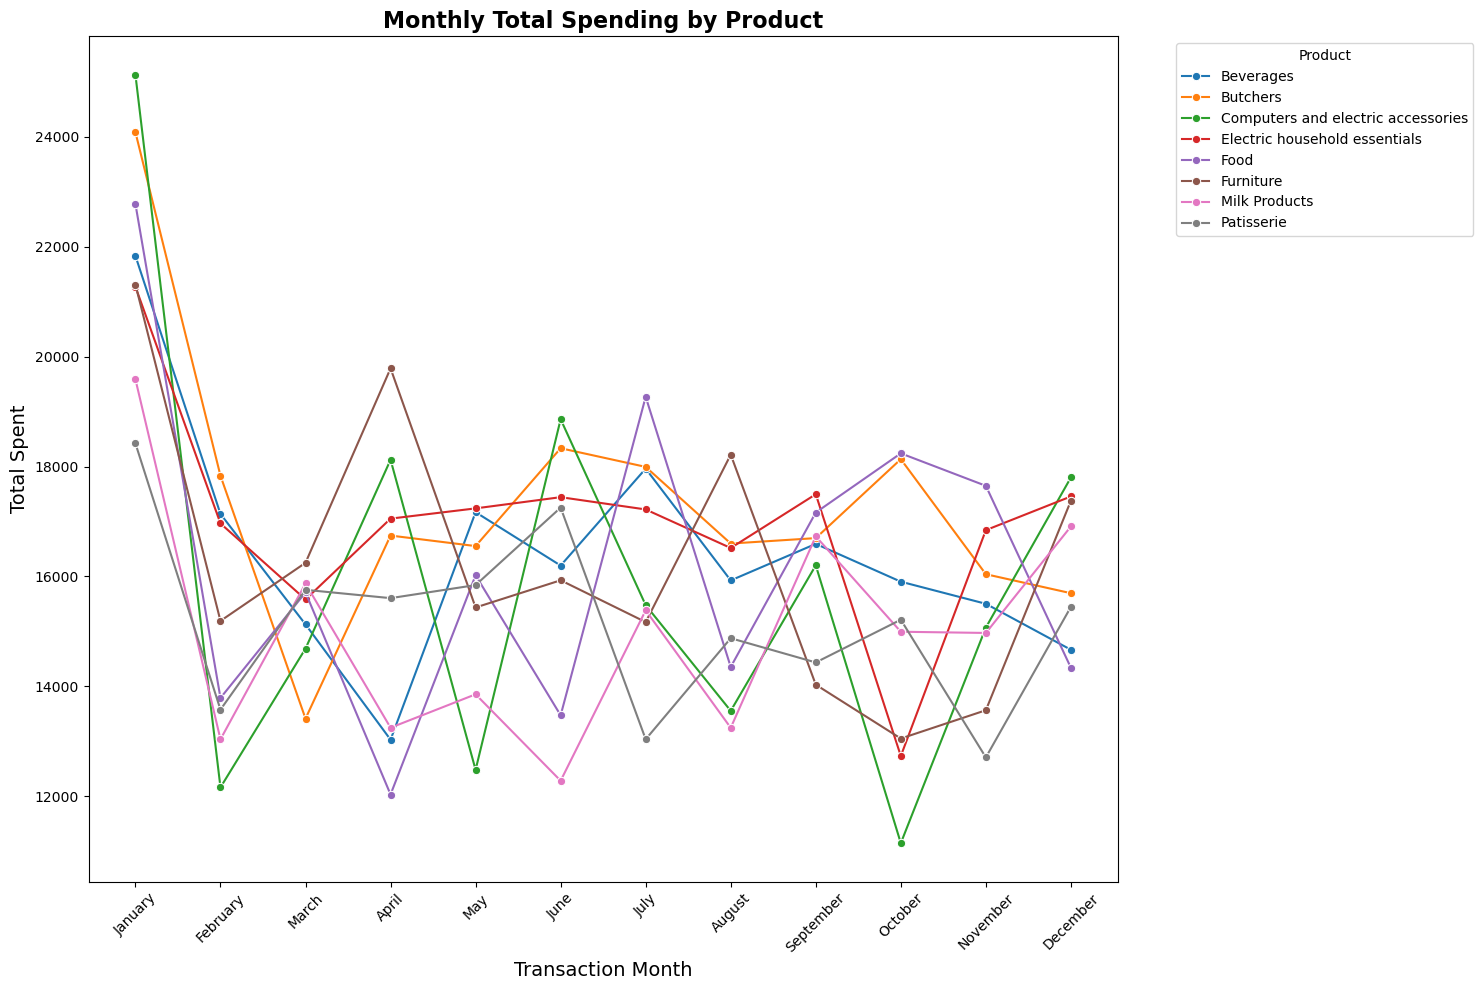

In [57]:
plt.figure(figsize=(15, 10))
sns.lineplot(
    x='Transaction_Month_Name',
    y='Total Spent',
    hue='Product',
    data=monthly_product_sales,
    marker='o'
)
plt.title("Monthly Total Spending by Product", fontsize=16, fontweight='bold')
plt.xlabel("Transaction Month", fontsize=14)
plt.ylabel("Total Spent", fontsize=14)
plt.xticks(rotation=45)
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [58]:
df = df.reset_index(drop=True)
df.insert(0, "Sl.No", range(1, len(df) + 1))
df.to_csv("cleaned_data.csv", index=False)
print(df.head())

   Sl.No Transaction ID        Product  Price/Unit  Quantity  Total Spent  \
0      1    TXN_6867343     Patisserie        18.5      10.0        185.0   
1      2    TXN_3731986  Milk Products        29.0       9.0        261.0   
2      3    TXN_9303719       Butchers        21.5       2.0         43.0   
3      4    TXN_9458126      Beverages        27.5       9.0        247.5   
4      5    TXN_4575373           Food        12.5       7.0         87.5   

   Payment Method Purchase_Mode Transaction Date Discount Applied  \
0  Digital Wallet        Online       2024-04-08             True   
1  Digital Wallet        Online       2023-07-23             True   
2     Credit Card        Online       2022-10-05            False   
3     Credit Card        Online       2022-05-07          Unknown   
4  Digital Wallet        Online       2022-10-02            False   

  Transaction_Month_Name Transaction Day  Transaction Quarter Revenue  \
0                  April          Monday         

#### OVERALL INSIGHTS

### 1. Data Quality & Preparation Insights

Missing values detected in Price/Unit, Quantity, and some categorical columns.

Filled missing numeric values using median imputation (robust to outliers).

Dropped duplicate rows and removed invalid records (zero or negative price/quantity).

Removed extreme outliers in Total Spent using group-wise IQR filtering for fairer distribution.

Recomputed Total Spent to ensure consistency after cleaning.

### 2. Univariate Analysis Insights

Total Spending: Right-skewed distribution — most customers spend in the lower range with a few high-value purchases.

Quantity: Majority of transactions involve small-to-medium quantities, indicating normal retail purchase behavior.

Price/Unit: Mostly concentrated around the median, but with some high-value premium products.

Purchase Mode: One channel dominates (e.g., Online or In-Store), highlighting a clear customer preference.

### 3. Bivariate Analysis Insights

Total Spent vs Payment Method: Clear differences in spending patterns — some methods linked to higher average spending.

Top-Selling Products: A small set of products contribute most of the total sales volume (Pareto effect).

Price/Unit vs Quantity: Weak negative correlation → quantity not strongly influenced by price per unit.

### 4. Multivariate Analysis Insights

Quantity is the strongest driver of Total Spent, followed by Price/Unit.

Product-wise spending patterns vary significantly across Payment Method and Purchase Mode, revealing customer segmentation opportunities.

Heatmap shows which product–channel combinations perform best, helping optimize inventory and marketing efforts.

### 5. Hypothesis Testing Results

ANOVA: Statistically significant differences in mean spending across payment methods (p < 0.05).

Pairwise T-Tests: Certain payment method pairs show significant differences, confirming that choice of payment mode impacts transaction value.

### 6. Business-Level Takeaways

Focus marketing efforts on top-selling products and high-value payment channels.

Encourage bulk purchases (quantity is the main spending driver) via bundle discounts or loyalty points.

Improve performance of under-utilized channels (Purchase Modes) by offering incentives.

Use insights to optimize inventory allocation across channels and payment method preferences.